### setup

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name, dir, screen_dpi=110):
    path = dir / f'{name}.png'
    fig.savefig(path)
    width = int(fig.get_size_inches()[0] * screen_dpi)   # show at screen size, not the 400-dpi pixel size
    plt.close(fig)
    display(Image(path, width=width))

### Sort-of-CLEVR example

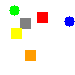

In [2]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(CHAP_DATASETS / 'soc_example.png'))

### SQOOP examples

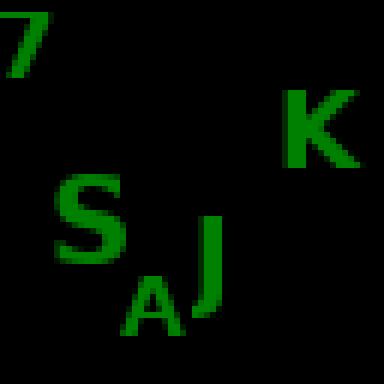

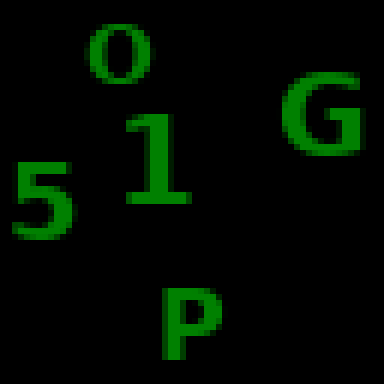

In [3]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

### results — run registry

Every result cell is one `cfg_hash` (the 10-char id in the `cfg:…` tag / `config.cfg_hash`; seeded reruns of a
config share it, so they aggregate automatically). `None` = not run yet — the cell is left out of the figures.

In [ ]:
ENTITY, TAG = 'niks_priv', 'v16'
SOC, SQ = 'sort_of_clevr', 'sqoop'
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
T_TEST = [0, 1, 2, 4, 6, 8, 12, 16]                # T values evaluated by the t_variance callback

MAIN = {
    SOC: {                       # label -> cfg_hash  (thesis-tier baselines as launched by run_sort_of_clevr)
        'Q-Only':      '5c938564b4',
        'CNN+MLP':     '7f69d35494',
        'RelNet':      '1bba57eaba',
        'FiLM':        'cce2a7dc79',
        'Transformer': 'd50b23e608',
        'Workspace':   'e2b5f79b1c',
        'SyncNet':     'bd2c173785',                # CANONICAL: identity_spatial + readout_prior=false
    },
    SQ: {                        # label -> {pair variety -> cfg_hash}
        'Q-Only':      {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
        'Conv+LSTM':   {1: '4dd2f8a5f6', 2: 'b838865278', 4: '11380cec6a', 8: '125ce8d50e', 18: '6828367e4c', 35: 'd6cbb5b004'},
        'RelNet':      {1: 'd91b42c323', 2: '41515ce582', 4: '46ef70288f', 8: 'f15b7d0159', 18: 'fd877702cb', 35: '18a92d8762'},
        'FiLM':        {1: '48c351e38b', 2: 'cbbfbd61a7', 4: '13e08caaa4', 8: '70f71488ff', 18: '4cf87adb37', 35: 'dd57cc6026'},
        'Transformer': {1: 'e5acac883a', 2: 'bd94a19a03', 4: '10eb8e1433', 8: '007a9674ee', 18: '17110fa882', 35: '13222c0aab'},
        'Workspace':   {1: '58a944c267', 2: '61a49532b2', 4: 'd12abb2e78', 8: 'fe996cfc81', 18: 'f3743655aa', 35: 'fa00371d63'},
        'SyncNet':     {1: '7c2f6df64c', 2: 'bb06c3147a', 4: '1bb0efa51c', 8: 'affb5412a5', 18: '9f272ac176', 35: '2b9eec406d'},   # 1/18 canonical (readout_prior=false); 2/4/8/35 bestofboth curve (prior ON -- rerun for parity)
        #               sync/hybrids/identity_partition_cnnenc
    },
}
FLOOR_MODEL = 'Q-Only'           # subtracted in the "accuracy above floor" plots

# Sort-of-CLEVR sweeps: x -> cfg_hash.  t_test is one run: its t_variance/* summaries give the sweep.
SWEEPS = {
    't_train':   {2: '2b9e6b890b', 4: '0ddfd86b22', 8: 'bd2c173785', 16: '50c47b416e'},
    'n_modules': {4: '0b69be29f7', 6: 'bd2c173785', 8: 'cc1f364afe', 12: '7352fba590'},
    'phase_dim': {2: 'ca9c20344c', 3: '4c476b02eb', 4: 'a9b3ddbed9', 6: 'bd2c173785', 8: 'f545ccea93'},
    't_test':    'bd2c173785',
}

# ---- ablation table: canonical model minus one component (label -> cfg_hash) ----
ABLATIONS = {
    SOC: {'canonical': 'bd2c173785', 'no_bias': 'd7072ec57d', 'hard_partition': '3986545b38', 'anchors_off': '96cb2d6dc8', 'cells_off': '8fbb02c9c0', 'silent': '77baf6a31a', 'static_addr': 'b09a365569', 'lines_attn': 'bbb6a6f7eb', 'cnn_stem': '5f683fd1b5'},
    SQ:  {18: {'canonical': '9f272ac176', 'no_bias': '20182acf1b', 'hard_partition': 'fc23127fcc', 'silent': 'a1142183d7', 'static_addr': '9daf23bd7b', 'lines_attn': '0e17b36177'},
          1:  {'canonical': '7c2f6df64c', 'no_bias': '6917200a5f', 'hard_partition': 'c30768ddf4', 'silent': 'c9c95bda21', 'static_addr': '1beba23c65', 'lines_attn': 'e582e0c1eb'}},
}
# ---- seed justification (SQOOP rhs=18): is the partition seed special? ----
SEED_JUSTIFICATION = {'canonical (partition, scale 4)': '9f272ac176', 'random': 'b14851cdf7', 'zero': '5f58c04ab4', 'scale1': 'b912886f99', 'scale2': '30100689be', 'scale8': '5d7d8e020a'}

# wandb summary columns behind each reported number
METRICS = {
    SOC: {'Overall': 'test_callbacks/accuracy', 'Non-relational': 'test_callbacks/non_relational_accuracy',
          'Binary': 'test_callbacks/binary_accuracy', 'Ternary': 'test_callbacks/ternary_accuracy'},
    SQ:  {'validation': 'eval_callbacks/accuracy', 'held-out': 'test_callbacks/accuracy'},
}
SUBTYPES = {                      # Table B.1 rows -> wandb column stem
    'Non-relational': {'Query shape': 'query_shape', 'Left of centre': 'left_of_centre', 'Top half': 'top_half'},
    'Binary':         {'Closest shape': 'closest_shape', 'Furthest shape': 'furthest_shape', 'Count same shape': 'count_same_shape'},
    'Ternary':        {'Count in box': 'count_in_box', 'On band': 'on_band', 'Count obtuse': 'count_obtuse'},
}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}', 'Binary': 't_variance/binary_mean_T{}', 'Ternary': 't_variance/ternary_mean_T{}'}
FAMILIES = list(METRICS[SOC])

### results — pull runs from wandb

One DataFrame per project, one row per finished run, config flattened to `model.name`-style columns plus every
scalar summary. Re-running reuses `RUNS` unless `REFRESH = True`. Falls back to `wandb_export_*.csv` next to the
notebook if the API is unreachable.

In [ ]:
REFRESH = False


def fetch(project):
    try:
        import wandb
        runs = wandb.Api(timeout=120).runs(f'{ENTITY}/{project}', filters={'tags': TAG, 'state': 'finished'})
        df = pd.json_normalize([{'created': str(r.created_at), **r.config,
                                 **{k: v for k, v in r.summary.items() if isinstance(v, (int, float))}}
                                for r in runs])
    except Exception as e:                              # offline / no API key
        print(f'{project}: wandb API unavailable ({e!r}); reading wandb_export_*.csv')
        df = pd.concat(pd.read_csv(p, low_memory=False) for p in Path('.').glob('wandb_export_*.csv'))
        df = df[(df['dataset.name'] == project) & (df['State'] == 'finished')].rename(columns={'Created': 'created'})
        df['cfg_hash'] = df['Tags'].str.extract(r'cfg:(\w{10})')[0]
    return df.sort_values('created').drop_duplicates(['cfg_hash', 'train.seed'], keep='last')   # latest run per seed


if REFRESH or 'RUNS' not in globals():
    RUNS = {ds: fetch(ds) for ds in (SOC, SQ)}
{ds: (len(df), df.cfg_hash.nunique()) for ds, df in RUNS.items()}


### results — the results tables

`stat(dataset, cfg_hash, column)` is the one lookup everything below goes through: mean, sd and seed count (in %)
over the runs of that config. One DataFrame per thesis table.

In [ ]:
def stat(dataset, cfg_hash, col):
    # (mean, sd, n) in % over the seeds of one config; (nan, nan, 0) if nothing to report
    df = RUNS[dataset]
    v = 100 * df.loc[df.cfg_hash == cfg_hash, col].dropna() if cfg_hash and col in df else pd.Series(dtype=float)
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else 0.0, len(v)) if len(v) else (np.nan, np.nan, 0)


def cell(dataset, cfg_hash, col):
    m, s, n = stat(dataset, cfg_hash, col)
    return '—' if np.isnan(m) else f'{m:.1f} ± {s:.1f} ({n})'


def params(dataset, cfg_hash):
    df = RUNS[dataset]
    n = df.loc[df.cfg_hash == cfg_hash, 'n_params'].dropna() if cfg_hash and 'n_params' in df else []
    return '—' if not len(n) else f'{n.iloc[0] / 1e6:.2f}M'


# canonical sweep values, read from the main run's config (defaults if the column is missing)
_r = RUNS[SOC][RUNS[SOC].cfg_hash == MAIN[SOC]['SyncNet']]
_main = _r.iloc[0] if len(_r) else pd.Series(dtype=object)
T_CANON, M_CANON, D_CANON = (int(_main[k]) if pd.notna(_main.get(k)) else d
                             for k, d in [('model.t_bus', 8), ('model.n_modules', 6), ('model.phase_dim', 6)])


def floor(fam):
    return np.nan_to_num(stat(SOC, MAIN[SOC][FLOOR_MODEL], METRICS[SOC][fam])[0])


#### Table 5.1 — Sort-of-CLEVR by question family

In [ ]:
soc_results = pd.DataFrame({
    'Params': {label: params(SOC, h) for label, h in MAIN[SOC].items()},
    **{fam: {label: cell(SOC, h, col) for label, h in MAIN[SOC].items()} for fam, col in METRICS[SOC].items()},
})
soc_results


#### Table B.1 — Sort-of-CLEVR by subtype

In [ ]:
rows = {('Overall', ''): METRICS[SOC]['Overall']}
for fam, subs in SUBTYPES.items():
    rows[(fam, '')] = METRICS[SOC][fam]
    rows.update({(fam, name): f'test_callbacks/{key}_accuracy' for name, key in subs.items()})
soc_subtypes = pd.DataFrame({label: {row: cell(SOC, h, col) for row, col in rows.items()} for label, h in MAIN[SOC].items()})
soc_subtypes.index.names = ['family', 'subtype']
soc_subtypes


#### Table B.2 — SQOOP by split and pair variety

In [ ]:
sqoop_results = pd.DataFrame({v: {(label, split): cell(SQ, by_v[v], col)
                                 for label, by_v in MAIN[SQ].items() for split, col in METRICS[SQ].items()}
                              for v in PAIR_VARIETY})
sqoop_results.columns.name = 'pair variety'
sqoop_results


#### Component ablations — canonical model minus one component

In [ ]:
soc_ablations = pd.DataFrame({fam: {label: cell(SOC, h, col) for label, h in ABLATIONS[SOC].items()}
                              for fam, col in METRICS[SOC].items()})
sqoop_ablations = pd.DataFrame({(v, split): {label: cell(SQ, cells.get(label), col) for label in ABLATIONS[SOC]}
                                for v, cells in ABLATIONS[SQ].items() for split, col in METRICS[SQ].items()})
sqoop_ablations.columns.names = ['pair variety', 'split']
display(soc_ablations, sqoop_ablations)


#### Seed justification — partition seed vs. alternatives, SQOOP pair variety 18

In [ ]:
seed_justification = pd.DataFrame({split: {label: cell(SQ, h, col) for label, h in SEED_JUSTIFICATION.items()}
                                   for split, col in METRICS[SQ].items()})
seed_justification


#### Tables 3.1 and C.1 — canonical and training configuration, from the main run's config

In [ ]:
CANONICAL = {'Modules M': 'model.n_modules', 'Phase dimension d': 'model.phase_dim', 'Internal steps T': 'model.t_bus',
             'Step size γ': 'model.dt', 'Module state d_h': 'model.module_dim', 'Message d_m': 'model.msg_dim',
             'Oscillators per cell': 'model.field_osc_dim', 'Field steps T_x': 'model.field_T', 'Field step size γ_x': 'model.field_dt',
             'Competition temperature β': 'model.slot_beta', 'Spatial bias initialisation b_k(p)': 'model.claim_prior'}
TRAINING = {'Optimiser': 'optim.optimiser', 'Learning rate': 'optim.lr', 'Weight decay': 'optim.weight_decay',
            'Schedule': 'optim.lr_scheduler', 'Warmup steps': 'optim.lr_scheduler_params.warmup_steps',
            'Batch size': 'train.train_bs', 'Gradient clipping': 'train.grad_clip', 'Optimisation steps': 'train.n_steps',
            'Precision': 'train.mixed_precision', 'Compilation': 'train.compile_model'}

canonical = pd.Series({k: _main.get(c, '—') for k, c in CANONICAL.items()}, name='value').fillna('—').to_frame()
training = pd.Series({k: _main.get(c, '—') for k, c in TRAINING.items()}, name='value').fillna('—').to_frame()
display(canonical, training)

# seeds per ablation cell
print({sweep: {x: stat(SOC, h, METRICS[SOC]['Overall'])[2] for x, h in cells.items()}
       for sweep, cells in SWEEPS.items() if sweep != 't_test'})
print('t_test seeds with t_variance:', stat(SOC, SWEEPS['t_test'], T_VARIANCE['Overall'].format(T_TEST[-1]))[2])


#### Tables A.1 and B.1–B.7 — dataset and per-model configuration

`config_table(prefix)` lists every `prefix.*` config key of the representative run on each dataset (the main
Sort-of-CLEVR run and the pair-variety-18 SQOOP run), so the appendix tables are read off the runs that produced
the results rather than transcribed from the yaml.

In [ ]:
def config_table(prefix, label='SyncNet'):
    reps = {'Sort-of-CLEVR': (SOC, MAIN[SOC].get(label)), 'SQOOP': (SQ, MAIN[SQ].get(label, {}).get(18))}
    cols = {}
    for name, (ds, h) in reps.items():
        r = RUNS[ds][RUNS[ds].cfg_hash == h]
        cols[name] = r.iloc[0].filter(like=prefix).dropna() if len(r) else pd.Series(dtype=object)
    t = pd.DataFrame(cols).fillna('—')
    return t.rename(index=lambda k: k.removeprefix(prefix))


# Table A.1: generator settings
dataset_config = config_table('dataset.')
display(dataset_config)

# Tables B.1–B.7: one per model (B.1's shared components are the rows common to all of them)
for label in dict.fromkeys([*MAIN[SOC], *MAIN[SQ]]):
    print(label)
    display(config_table('model.', label))


### results — Sort-of-CLEVR ablation plots

In [ ]:
def ablation(cells, xlabel, canon, name, cols=lambda x: METRICS[SOC]):
    """cells: {x: cfg_hash}; cols(x): {family: wandb column}.  Empty cells are skipped."""
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for fam in FAMILIES:
        pts = [(x, *stat(SOC, h, cols(x).get(fam))[:2]) for x, h in cells.items()]
        pts = [(x, m, s) for x, m, s in pts if not np.isnan(m)]
        if pts:
            x, m, s = map(np.array, zip(*pts))
            ax.plot(x, m, marker='o', markersize=3, label=fam)
            ax.fill_between(x, m - s, m + s, alpha=0.15)
    ax.axvline(canon, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xticks(list(cells))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (%)')
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, name, CHAP_RESULTS)


ablation({T: SWEEPS['t_test'] for T in T_TEST}, r'Test-time steps $T_{\mathrm{test}}$', T_CANON, 'soc_ablation_t_test',
         cols=lambda T: {fam: col.format(T) for fam, col in T_VARIANCE.items()})
ablation(SWEEPS['t_train'], r'Internal steps $T$ (train $=$ test)', T_CANON, 'soc_ablation_t_train')
ablation(SWEEPS['n_modules'], r'Number of modules $M$', M_CANON, 'soc_ablation_n_modules')
ablation(SWEEPS['phase_dim'], r'Phase dimension $d$', D_CANON, 'soc_ablation_phase_dim')


### results — joint train/test T (3D surface + heatmap)

In [ ]:
# every t_train run carries its own t_variance sweep, which gives the (train, test) grid
tr = [T for T, h in SWEEPS['t_train'].items() if T > 0 and stat(SOC, h, T_VARIANCE['Overall'].format(T))[2]]
te = [T for T in T_TEST if T > 0]
Z = np.array([[stat(SOC, SWEEPS['t_train'][Ttr], T_VARIANCE['Overall'].format(Tte))[0] for Tte in te] for Ttr in tr])
TR, TE = np.meshgrid(np.log2(tr), np.log2(te), indexing='ij')

if len(tr) < 2:
    print(f'joint T grid needs t_variance summaries on ≥2 t_train runs (have {len(tr)})')
else:
    fig = plt.figure(figsize=(4.5, 3.4))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TR, TE, Z, cmap='viridis', edgecolor='white', linewidth=0.3)
    diag = [Z[i, te.index(t)] for i, t in enumerate(tr)]
    ax.plot(np.log2(tr), np.log2(tr), diag, color='C3', marker='o', markersize=3, label=r'$T_{\mathrm{test}}=T_{\mathrm{train}}$')
    ax.set_xticks(np.log2(tr), tr); ax.set_yticks(np.log2(te), te)
    ax.set_xlabel(r'$T_{\mathrm{train}}$'); ax.set_ylabel(r'$T_{\mathrm{test}}$'); ax.set_zlabel('Accuracy (%)')
    ax.view_init(elev=25, azim=-128)
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, 'soc_ablation_t_surface', CHAP_RESULTS)

    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    im = ax.imshow(Z, cmap='viridis', origin='lower')
    ax.set_xticks(range(len(te)), te); ax.set_yticks(range(len(tr)), tr)
    ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
    fig.colorbar(im, label='Accuracy (%)')
    save_show(fig, 'soc_ablation_t_heatmap', CHAP_RESULTS)


### results — SQOOP (Table 5.3)

In [ ]:
def sq(name, v, split):
    return stat(SQ, MAIN[SQ][name][v], METRICS[SQ][split])[:2]


SQOOP_MODELS = [name for name in MAIN[SQ] if any(not np.isnan(sq(name, v, 'held-out')[0]) for v in PAIR_VARIETY)]

fig, axes = plt.subplots(2, 1, figsize=(6.2, 4.4), sharex=True)
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = zip(*[sq(name, v, split) for v in PAIR_VARIETY])
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_ylim(40, 100)
    ax.set_ylabel(f'{split} accuracy (%)')

axes[-1].set_xticks(x, PAIR_VARIETY)
axes[-1].set_xlabel('Pair variety')
axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_bars_stacked', CHAP_RESULTS)

In [ ]:
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = zip(*[sq(name, v, split) for v in PAIR_VARIETY])
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_xticks(x, PAIR_VARIETY)
    ax.set_xlabel('Pair variety')
    ax.set_title(split)
    ax.set_ylim(40, 100)
axes[0].set_ylabel('Accuracy (%)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=7, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.2))
save_show(fig, 'sqoop_results_bars', CHAP_RESULTS)

# alternative: held-out accuracy vs pair variety, one line per model
fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    m = [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY]
    ax.plot(PAIR_VARIETY, m, marker='o', markersize=3, label=name)
ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right')
save_show(fig, 'sqoop_results_lines', CHAP_RESULTS)

In [ ]:
fig, (ax_val, ax_held) = plt.subplots(2, 1, figsize=(6.2, 3.8), sharex=True,
                                      height_ratios=[1, 2.5])
for name in SQOOP_MODELS:
    held = [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY]
    val = [sq(name, v, 'validation')[0] for v in PAIR_VARIETY]
    line, = ax_held.plot(PAIR_VARIETY, held, marker='o', markersize=3, label=name)
    ax_val.plot(PAIR_VARIETY, val, marker='o', markersize=3, color=line.get_color())

ax_val.set_ylim(95, 100)
ax_val.set_ylabel('validation (%)')
ax_held.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax_held.set_ylim(40, 100)
ax_held.set_ylabel('held-out (%)')
ax_held.set_xscale('log'); ax_held.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax_held.minorticks_off()
ax_held.set_xlabel('Pair variety')
ax_held.legend(frameon=False, fontsize=7, ncol=2, loc='lower right')
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_lines_split', CHAP_RESULTS)